[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset saved
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Feedback_ID    50 non-null     int64 
 1   Client_Name    50 non-null     object
 2   Service        50 non-null     object
 3   Feedback_Text  50 non-null     object
 4   Rating         50 non-null     int64 
 5   Sentiment      50 non-null     object
dtypes: int64(2), object(4)
memory usage: 2.5+ KB
None
       Feedback_ID     Rating
count     50.00000  50.000000
mean      25.50000   3.020000
std       14.57738   1.671978
min        1.00000   1.000000
25%       13.25000   1.000000
50%       25.50000   3.000000
75%       37.75000   5.000000
max       50.00000   5.000000
Sentiment
Positive    25
Negative    25
Name: count, dtype: int64
TF-IDF shape: (50, 30)
Accuracy: 0.8
              precision    recall  f1-score   support

    Negative       1.00      0.71      0.83         7
   

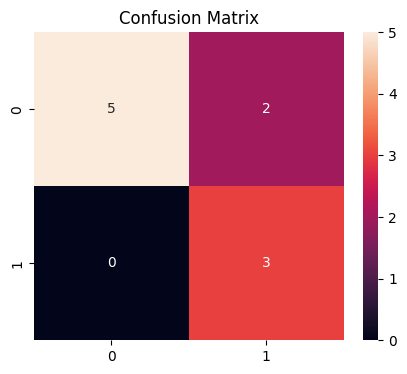

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

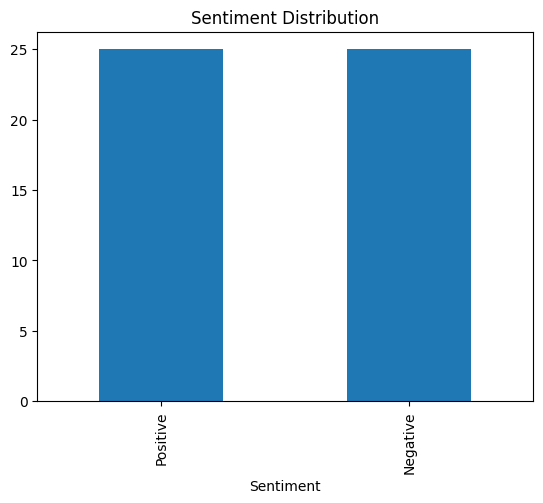

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

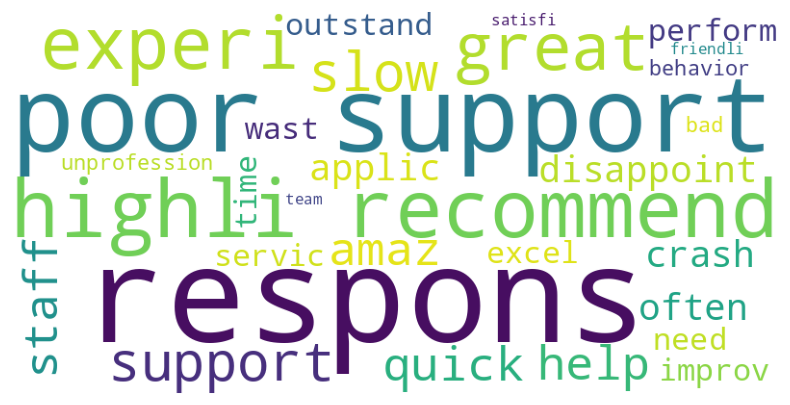

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TASK 7 COMPLETED SUCCESSFULLY 🚀


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All CSV and PNG files downloaded successfully!


In [17]:
# =========================
# INSTALL LIBRARIES
# =========================
!pip install nltk wordcloud scikit-learn pandas matplotlib seaborn

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud
from google.colab import files

# =========================
# NLTK DOWNLOADS
# =========================
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# =========================
# CREATE DATASET
# =========================
positive_feedback = [
    "Excellent service","Great support","Very satisfied","Amazing experience",
    "Helpful staff","Quick response","Highly recommended","Friendly team",
    "Outstanding performance","Easy to use"
]

negative_feedback = [
    "Poor support","Bad experience","Very disappointed","Slow response",
    "Needs improvement","Application crashes often","Not satisfied",
    "Terrible service","Waste of time","Unprofessional behavior"
]

data = []

for i in range(1, 51):
    if i <= 25:
        feedback = random.choice(positive_feedback)
        sentiment = "Positive"
        rating = random.randint(4,5)
    else:
        feedback = random.choice(negative_feedback)
        sentiment = "Negative"
        rating = random.randint(1,2)

    data.append([i, f"Client_{i}",
                 random.choice(["Web","Mobile","Support"]),
                 feedback, rating, sentiment])

df = pd.DataFrame(data, columns=[
    "Feedback_ID","Client_Name","Service",
    "Feedback_Text","Rating","Sentiment"
])

# =========================
# SAVE DATASET
# =========================
df.to_csv("coretech_feedback.csv", index=False)
print("Dataset saved")

# =========================
# BASIC INFO
# =========================
print(df.info())
print(df.describe())
print(df['Sentiment'].value_counts())

# =========================
# TEXT CLEANING
# =========================
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [stemmer.stem(w) for w in words]
    return " ".join(words)

df["Cleaned_Text"] = df["Feedback_Text"].apply(clean_text)

# =========================
# TF-IDF
# =========================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Cleaned_Text"])
y = df["Sentiment"]

print("TF-IDF shape:", X.shape)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# NAIVE BAYES MODEL
# =========================
model = MultinomialNB()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

files.download("confusion_matrix.png")

# =========================
# SENTIMENT BAR CHART
# =========================
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.savefig("sentiment_distribution.png")
plt.show()

files.download("sentiment_distribution.png")

# =========================
# WORD CLOUD
# =========================
text = " ".join(df["Cleaned_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("wordcloud.png")
plt.show()

files.download("wordcloud.png")

# =========================
# SAVE PREDICTIONS
# =========================
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv("sentiment_predictions.csv", index=False)

files.download("sentiment_predictions.csv")

# =========================
# FINAL MESSAGE
# =========================
print("TASK 7 COMPLETED SUCCESSFULLY 🚀")# ==============================
# Download All CSV and PNG Files
# ==============================

from google.colab import files

# Download CSV files
files.download("coretech_feedback.csv")
files.download("sentiment_predictions.csv")

# Download PNG files
files.download("confusion_matrix.png")
files.download("sentiment_distribution.png")
files.download("wordcloud.png")

print("All CSV and PNG files downloaded successfully!")